In [39]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [28]:
X_normal, _ = make_blobs(n_samples=300,n_features=2,centers=2,cluster_std=1.0,random_state=42)

In [34]:
np.random.seed(42)
X_outliers = np.random.uniform(low=6,high=12,size=(20,2))

In [35]:
X = np.vstack([X_normal,X_outliers])

In [36]:
df = pd.DataFrame(X,columns=["f1","f2"])
df["outliers"] = [0]*len(X_normal)+[1]*len(X_outliers)

In [37]:
df.head()

,f1,f2,outliers
0,4.978375,1.557882,0
1,5.278471,0.311650,0
2,-2.522695,7.956575,0
3,5.186976,1.770977,0
4,4.929654,4.048570,0


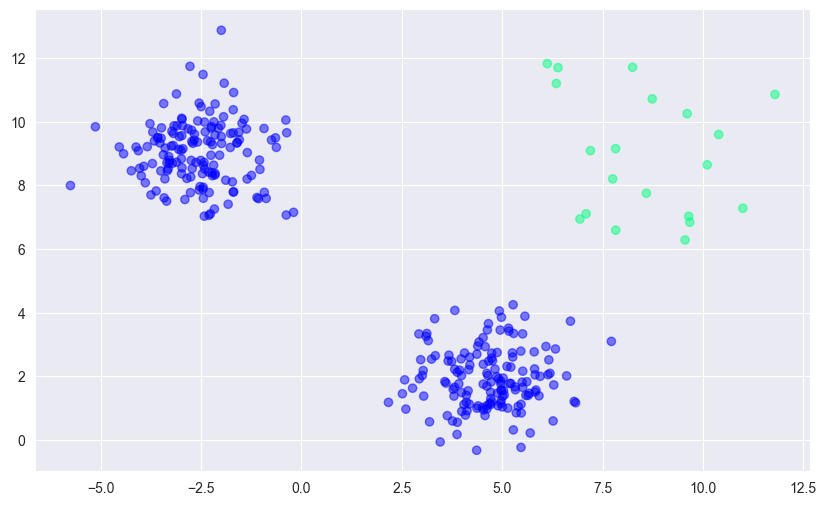

In [40]:
plt.figure(figsize=(10,6))
plt.scatter(df["f1"],df["f2"],c=df.outliers,cmap="winter",alpha=0.5)
df.drop(columns="outliers",inplace=True)

In [41]:
clf = IsolationForest(contamination=0.1)
clf.fit(df)
pred = clf.predict(df)

In [42]:
pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

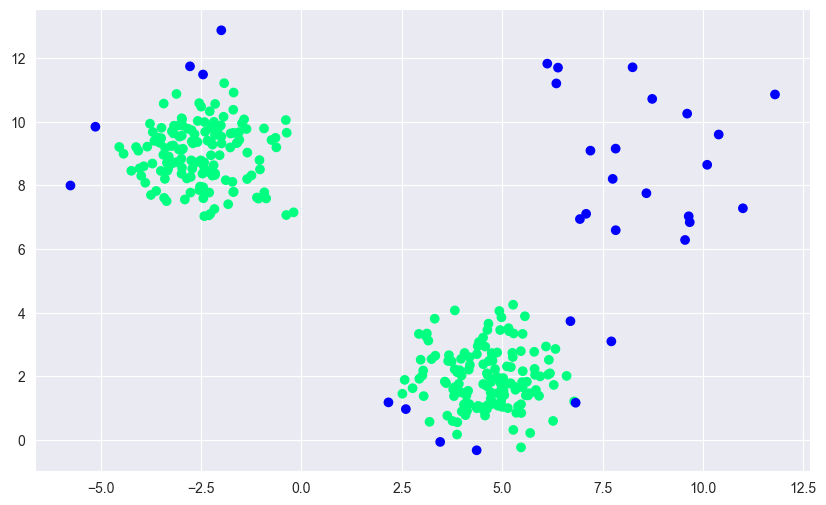

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(df["f1"],df["f2"],c=pred,cmap="winter")